In [3]:
import sys
print(sys.executable)

c:\Users\Hp\anaconda3\python.exe


In [4]:

# IMPORTS

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import sys
print(sys.executable)

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
import xgboost as xgb
import shap

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to path:", project_root)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Hp\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Hp\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\Hp\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io_loop.start()
  File "c:\Users\Hp\anaconda3\Lib\site-packages\tornado\

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
from src.preprocessing import *

In [ ]:


test_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_testing-set.csv"
train_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_training-set.csv"

df = pd.read_csv("C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_testing-set.csv")

# Remove leakage columns
df = df.drop(columns=["id", "attack_cat"], errors="ignore")
test_df = pd.read_csv(test_path)
# Encode categorical features
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("label", axis=1)
y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Train only on normal traffic
X_train_normal = X_train[y_train == 0]

scaler_iso = StandardScaler()
X_train_normal = scaler_iso.fit_transform(X_train_normal)
X_test_iso = scaler_iso.transform(X_test)

iso_model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_model.fit(X_train_normal)

iso_preds = iso_model.predict(X_test_iso)
iso_preds = np.where(iso_preds == -1, 1, 0)

iso_metrics = {
    "accuracy": accuracy_score(y_test, iso_preds),
    "precision": precision_score(y_test, iso_preds),
    "recall": recall_score(y_test, iso_preds),
    "f1_score": f1_score(y_test, iso_preds)
}

iso_metrics

{'accuracy': 0.5783081314143438,
 'precision': 0.7970646344905448,
 'recall': 0.3120786827273732,
 'f1_score': 0.4485387547649301}

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix,recall_score
import numpy as np


In [ ]:
#isolation forest
# Train only on normal traffic
X_train_normal = X_train[y_train == 0]

scaler_iso = StandardScaler()
X_train_normal = scaler_iso.fit_transform(X_train_normal)
X_test_iso = scaler_iso.transform(X_test)

iso_model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_model.fit(X_train_normal)

iso_preds = iso_model.predict(X_test_iso)
iso_preds = np.where(iso_preds == -1, 1, 0)

iso_metrics = {
    "accuracy": accuracy_score(y_test, iso_preds),
    "precision": precision_score(y_test, iso_preds),
    "recall": recall_score(y_test, iso_preds),
    "f1_score": f1_score(y_test, iso_preds)
}

iso_metrics


{'accuracy': 0.5783081314143438,
 'precision': 0.7970646344905448,
 'recall': 0.3120786827273732,
 'f1_score': 0.4485387547649301}

In [ ]:
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train)
X_test_xgb = scaler_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_xgb, y_train)

xgb_preds = xgb_model.predict(X_test_xgb)

xgb_metrics = {
    "accuracy": accuracy_score(y_test, xgb_preds),
    "precision": precision_score(y_test, xgb_preds),
    "recall": recall_score(y_test, xgb_preds),
    "f1_score": f1_score(y_test, xgb_preds)
}

xgb_metrics

{'accuracy': 0.9739478957915831,
 'precision': 0.9822107854106064,
 'recall': 0.9701624488893801,
 'f1_score': 0.9761494412631345}

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_mse = mean_squared_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost MAE:", xgb_mae)
print("XGBoost MSE:", xgb_mse)
print("XGBoost R2 :", xgb_r2)

NameError: name 'y_test' is not defined

In [ ]:
hybrid_preds = []

for i in range(len(X_test)):
    if xgb_preds[i] == 1:
        hybrid_preds.append(1)
    elif iso_preds[i] == 1:
        hybrid_preds.append(1)
    else:
        hybrid_preds.append(0)

hybrid_metrics = {
    "accuracy": accuracy_score(y_test, hybrid_preds),
    "precision": precision_score(y_test, hybrid_preds),
    "recall": recall_score(y_test, hybrid_preds),
    "f1_score": f1_score(y_test, hybrid_preds)
}

hybrid_metrics

{'accuracy': 0.9316208173923605,
 'precision': 0.910050719387227,
 'recall': 0.9715990717206321,
 'f1_score': 0.9398182789951898}

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Isolation Forest", "XGBoost", "Hybrid"],
    "Accuracy": [iso_metrics["accuracy"], xgb_metrics["accuracy"], hybrid_metrics["accuracy"]],
    "Precision": [iso_metrics["precision"], xgb_metrics["precision"], hybrid_metrics["precision"]],
    "Recall": [iso_metrics["recall"], xgb_metrics["recall"], hybrid_metrics["recall"]],
    "F1 Score": [iso_metrics["f1_score"], xgb_metrics["f1_score"], hybrid_metrics["f1_score"]]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Isolation Forest,0.578308,0.797065,0.312079,0.448539
1,XGBoost,0.973948,0.982211,0.970162,0.976149
2,Hybrid,0.931621,0.910051,0.971599,0.939818


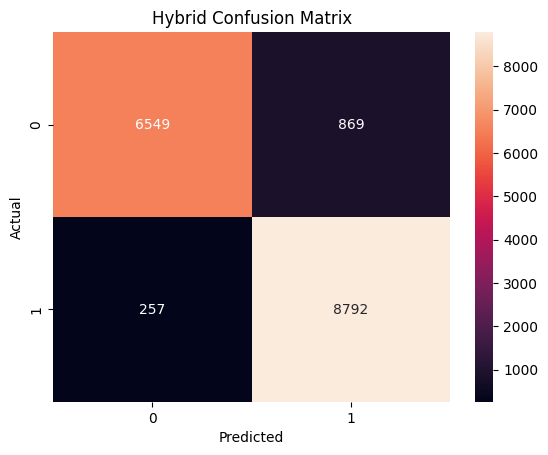

In [ ]:
cm = confusion_matrix(y_test, hybrid_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Hybrid Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
print("y_test length:", len(y_test))
print("iso_preds length:", len(iso_preds))
print("xgb_preds length:", len(xgb_preds))
print("hybrid_preds length:", len(hybrid_preds))



y_test length: 82332
iso_preds length: 16467
xgb_preds length: 16467
hybrid_preds length: 16467



Full Model Comparison:

              Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Isolation Forest  0.578308   0.797065  0.312079  0.448539  0.730939
1           XGBoost  0.973948   0.982211  0.970162  0.976149  0.997212
2            Hybrid  0.931621   0.910051  0.971599  0.939818  0.927226


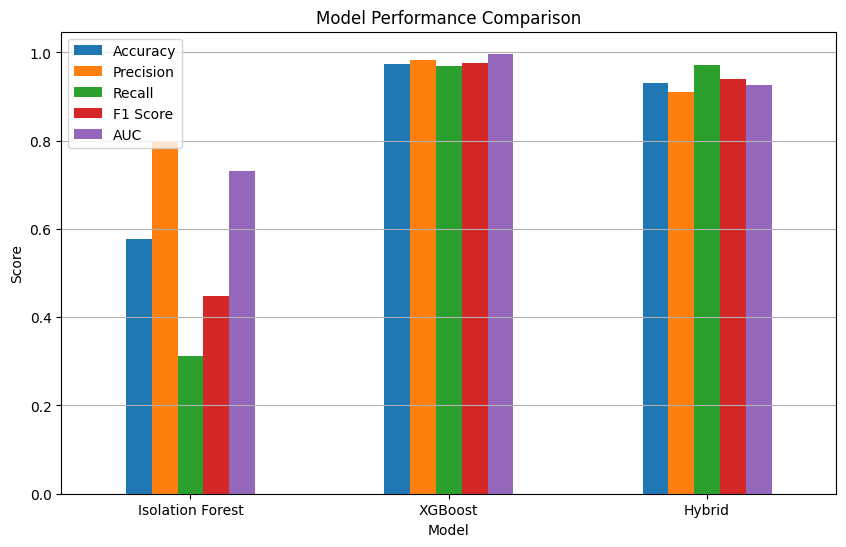

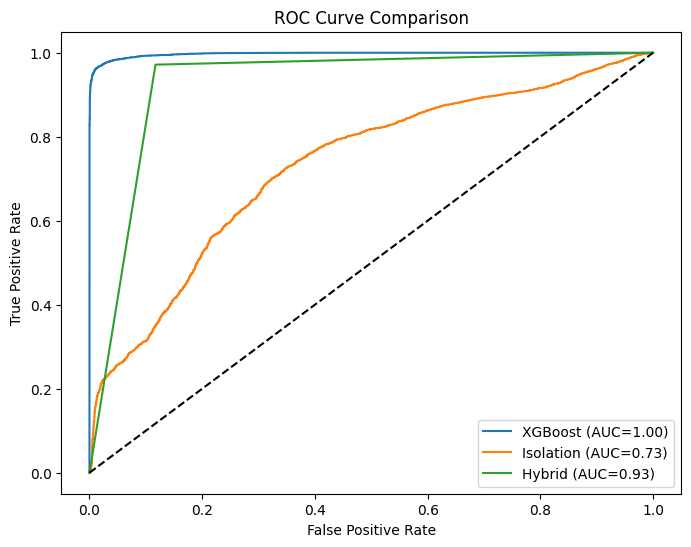

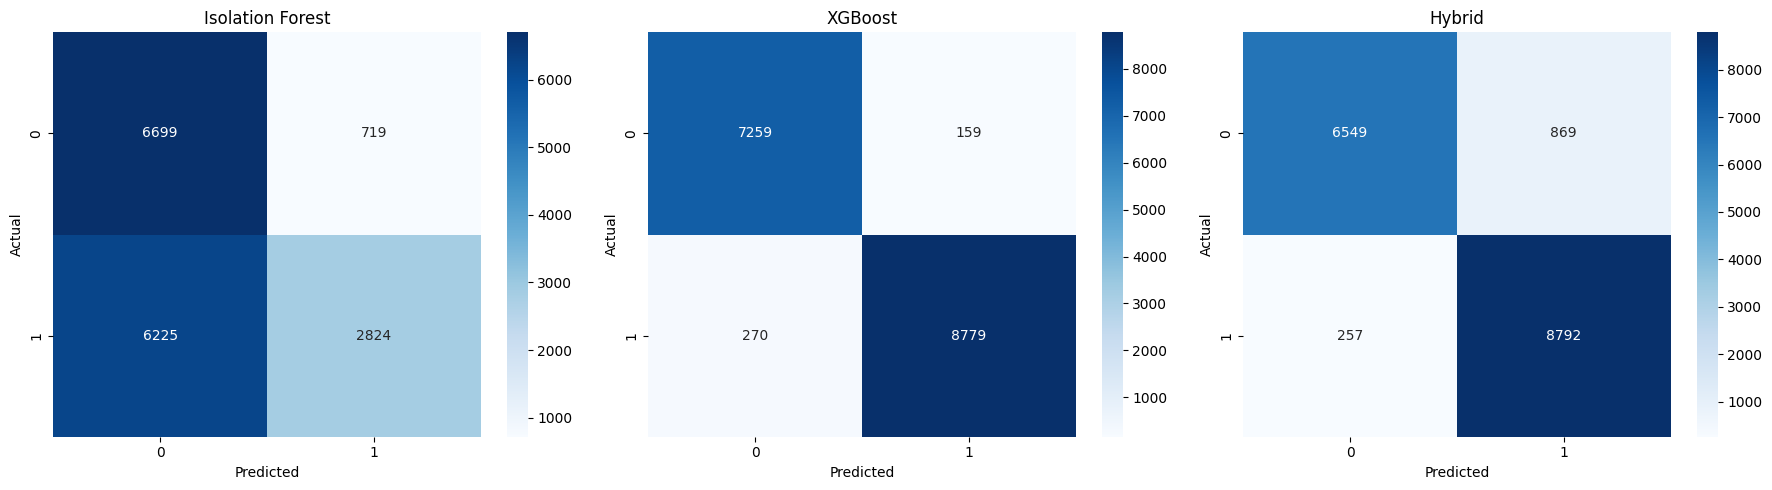

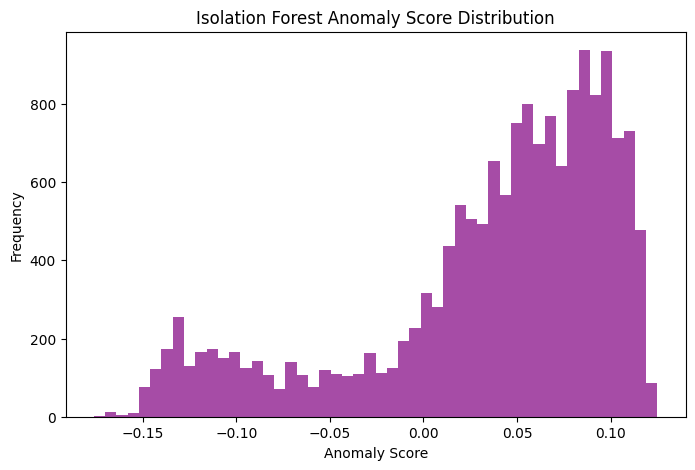

In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.model_selection import train_test_split
import xgboost as xgb

# ==========================================
# LOAD DATA
# ==========================================
train_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_training-set.csv"
test_path = "C:/Users/Hp/Desktop/XAI-ZERODAY-IDS/data/raw/UNSW_NB15_testing-set.csv"

df = pd.read_csv(test_path)

# Remove leakage columns
df = df.drop(columns=["id", "attack_cat"], errors="ignore")

# Encode categorical features
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("label", axis=1)
y = df["label"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# ISOLATION FOREST
# ==========================================
X_train_normal = X_train[y_train == 0]

scaler_iso = StandardScaler()
X_train_normal = scaler_iso.fit_transform(X_train_normal)
X_test_iso = scaler_iso.transform(X_test)

iso_model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_model.fit(X_train_normal)

iso_preds = iso_model.predict(X_test_iso)
iso_preds = np.where(iso_preds == -1, 1, 0)

iso_metrics = {
    "accuracy": accuracy_score(y_test, iso_preds),
    "precision": precision_score(y_test, iso_preds),
    "recall": recall_score(y_test, iso_preds),
    "f1_score": f1_score(y_test, iso_preds)
}


# XGBOOST

scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train)
X_test_xgb = scaler_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_xgb, y_train)
xgb_preds = xgb_model.predict(X_test_xgb)

xgb_metrics = {
    "accuracy": accuracy_score(y_test, xgb_preds),
    "precision": precision_score(y_test, xgb_preds),
    "recall": recall_score(y_test, xgb_preds),
    "f1_score": f1_score(y_test, xgb_preds)
}

# HYBRID MODEL

hybrid_preds = []
for i in range(len(X_test)):
    if xgb_preds[i] == 1:
        hybrid_preds.append(1)
    elif iso_preds[i] == 1:
        hybrid_preds.append(1)
    else:
        hybrid_preds.append(0)

hybrid_preds = np.array(hybrid_preds)

hybrid_metrics = {
    "accuracy": accuracy_score(y_test, hybrid_preds),
    "precision": precision_score(y_test, hybrid_preds),
    "recall": recall_score(y_test, hybrid_preds),
    "f1_score": f1_score(y_test, hybrid_preds)
}

# FINAL COMPARISON + VISUALIZATION

# Probabilities / scores
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
iso_scores = iso_model.decision_function(X_test_iso)

# AUC
iso_auc = roc_auc_score(y_test, -iso_scores)
xgb_auc = roc_auc_score(y_test, xgb_probs)
try:
    hybrid_auc = roc_auc_score(y_test, hybrid_preds)
except ValueError:
    hybrid_auc = np.nan

# Comparison table
comparison_full = pd.DataFrame({
    "Model": ["Isolation Forest", "XGBoost", "Hybrid"],
    "Accuracy": [iso_metrics["accuracy"], xgb_metrics["accuracy"], hybrid_metrics["accuracy"]],
    "Precision": [iso_metrics["precision"], xgb_metrics["precision"], hybrid_metrics["precision"]],
    "Recall": [iso_metrics["recall"], xgb_metrics["recall"], hybrid_metrics["recall"]],
    "F1 Score": [iso_metrics["f1_score"], xgb_metrics["f1_score"], hybrid_metrics["f1_score"]],
    "AUC": [iso_auc, xgb_auc, hybrid_auc]
})

print("\nFull Model Comparison:\n")
print(comparison_full)

# Bar chart
comparison_full.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

# ROC curves
plt.figure(figsize=(8,6))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={xgb_auc:.2f})")
fpr_iso, tpr_iso, _ = roc_curve(y_test, -iso_scores)
plt.plot(fpr_iso, tpr_iso, label=f"Isolation (AUC={iso_auc:.2f})")
if not np.isnan(hybrid_auc):
    fpr_hyb, tpr_hyb, _ = roc_curve(y_test, hybrid_preds)
    plt.plot(fpr_hyb, tpr_hyb, label=f"Hybrid (AUC={hybrid_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1,3, figsize=(18,5))
models = {"Isolation Forest": iso_preds, "XGBoost": xgb_preds, "Hybrid": hybrid_preds}
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# Isolation score distribution
plt.figure(figsize=(8,5))
plt.hist(iso_scores, bins=50, color="purple", alpha=0.7)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()


In [ ]:
import numpy
import pandas
print("Numpy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Working ✅")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject